# Hands-on 4 — Inside the inference engine: MAP vs MGVI vs geoVI vs NUTS

**Course:** NIFTy in a day · **Session:** 16:00 – 16:45

`optimize_kl` has many switches. Experts know *what each one does to the posterior*. On a 2-parameter problem we
can compute the exact posterior on a grid, so we can **see** the approximation each method makes.

**You will learn**
1. How MAP, MGVI (`linear_resample`), and geoVI (`nonlinear_resample`) differ — visually.
2. How to get (asymptotically) exact samples with NUTS (`jft.blackjax_nuts`) for validation.
3. The remaining `optimize_kl` controls: `n_samples` schedules, `point_estimates`, `constants`, `callback`, `odir`/`resume`.
4. Diagnostics: `jft.minisanity` (reduced χ²), and model comparison with the **ELBO**.

In [1]:
import jax
import jax.numpy as jnp
import jax.random as random
import matplotlib.pyplot as plt
import numpy as np

import nifty.re as jft

jax.config.update("jax_enable_x64", True)
plt.rcParams["figure.dpi"] = 90

## 1. A deliberately non-Gaussian toy problem

Two latent parameters, both standard-normal a priori. We measure $\xi_1 + \xi_2^2$ precisely and $\xi_1$ poorly.
Because only $\xi_2^2$ enters, the sign of $\xi_2$ is unidentifiable → a curved, two-armed ("banana") posterior.

In [2]:
class Banana(jft.Model):
    def __init__(self):
        self.a = jft.NormalPrior(0.0, 1.0, name="xi1")
        self.b = jft.NormalPrior(0.0, 1.0, name="xi2")
        super().__init__(init=self.a.init | self.b.init)

    def __call__(self, xi):
        x1, x2 = self.a(xi), self.b(xi)
        return jnp.stack([x1 + x2**2, x1])


model = Banana()
data = jnp.array([1.5, 0.5])
noise_std = jnp.array([0.3, 1.0])
lh = jft.Gaussian(data, noise_std_inv=lambda r: r / noise_std).amend(model)

# Exact posterior on a grid: P(xi|d) ∝ exp(-H(d|xi) - |xi|^2/2)
g1, g2 = np.meshgrid(np.linspace(-2, 3, 300), np.linspace(-2.5, 2.5, 300))
H = jax.vmap(jax.vmap(lambda a, b: lh({"xi1": a, "xi2": b}) + 0.5 * (a**2 + b**2)))(g1, g2)
post = np.exp(-(H - H.min()))

def show(ax, pts=None, mean=None, title=""):
    ax.contourf(g1, g2, post, 15, cmap="Blues")
    if pts is not None:
        ax.plot(pts[:, 0], pts[:, 1], ".", c="C3", ms=4, alpha=0.7)
    if mean is not None:
        ax.plot(*mean, "X", c="k", ms=11)
    ax.set_title(title); ax.set_xlabel(r"$\xi_1$"); ax.set_ylabel(r"$\xi_2$")

def as_pts(samples):
    return np.stack([np.array([s["xi1"], s["xi2"]]) for s in samples])

assuming a diagonal covariance matrix;
setting `cov_inv` to `std_inv(ones_like(data))**2`


## 2. Run every method

`optimize_kl` logs every iteration to stderr: the energy `E`, the number of Newton steps, and the
**reduced χ²** of data residuals and latent parameters (more on those in §6). Read those logs — they are your main
convergence monitor on real problems.

<frozen genericpath>:39: RuntimeWarning: bool is used as a file descriptor
OPTIMIZE_KL: Starting 0001


OPTIMIZE_KL: Iteration 0001 E:+6.1375e-01
OPTIMIZE_KL: #(KL minimization steps) 8
OPTIMIZE_KL: Likelihood residual(s):
'reduced Chi²:   0.011±     0.0, avg:   +0.075±     0.0, #dof:      2'

OPTIMIZE_KL: Prior residual(s):
xi1                     :: 'reduced Chi²:    0.25±     0.0, avg:     +0.5±     0.0, #dof:      1'
xi2                     :: 'reduced Chi²:    0.95±     0.0, avg:    +0.98±     0.0, #dof:      1'




OPTIMIZE_KL: Starting 0002


OPTIMIZE_KL: Iteration 0002 E:+6.1375e-01
OPTIMIZE_KL: #(KL minimization steps) 1
OPTIMIZE_KL: Likelihood residual(s):
'reduced Chi²:   0.011±     0.0, avg:   +0.075±     0.0, #dof:      2'

OPTIMIZE_KL: Prior residual(s):
xi1                     :: 'reduced Chi²:    0.25±     0.0, avg:     +0.5±     0.0, #dof:      1'
xi2                     :: 'reduced Chi²:    0.95±     0.0, avg:    +0.98±     0.0, #dof:      1'




OPTIMIZE_KL: Starting 0003


...

CG: WARNING: energy increased


CG: WARNING: energy increased


N: Iteration Limit Reached


OPTIMIZE_KL: Iteration 0006 E:+1.4205e+00
OPTIMIZE_KL: #(Nonlinear sampling steps) (3, 3, 20, 4, 4, 5, 20, 4, 4, 3, 4, 4, 4, 9, 3, 3, 3, 4, 3, 3, 4, 20, 4, 15, 4, 14, 5, 15, 4, 3, 13, 4, 20, 4, 9, 4, 20, 4, 5, 20, 14, 5, 5, 15, 3, 3, 4, 20, 20, 4, 9, 4, 12, 4, 4, 3, 3, 3, 20, 4, 20, 4, 3, 3, 4, 8, 4, 20, 5, 4, 3, 3, 20, 4, 20, 4, 4, 4, 3, 4, 20, 4, 3, 4, 4, 20, 4, 8, 20, 4, 20, 4, 3, 3, 4, 5, 4, 20, 3, 3, 20, 4, 20, 4, 4, 20, 20, 4, 4, 3, 3, 3, 3, 4, 10, 4, 4, 20, 20, 4)
OPTIMIZE_KL: #(KL minimization steps) 6
OPTIMIZE_KL: Likelihood residual(s):
'reduced Chi²:    0.67±    0.59, avg:  -0.0072±    0.59, #dof:      2'

OPTIMIZE_KL: Prior residual(s):
xi1                     :: 'reduced Chi²:     1.0±    0.72, avg:    +0.91±    0.44, #dof:      1'
xi2                     :: 'reduced Chi²:    0.47±     0.4, avg:   +0.092±    0.68, #dof:      1'




BLACKJAX_MCMC: Mean Energy:+1.4440e+00
BLACKJAX_MCMC: Likelihood residual(s):
'reduced Chi²:    0.67±    0.71, avg:   +0.045±    0.59, #dof:      2'

BLACKJAX_MCMC: Prior residual(s):
xi1                     :: 'reduced Chi²:    0.74±    0.72, avg:    +0.62±     0.6, #dof:      1'
xi2                     :: 'reduced Chi²:    0.82±    0.63, avg:   +0.026±    0.91, #dof:      1'

BLACKJAX_MCMC: Effective samples size(s):
xi1                     :: 260
xi2                     :: 48




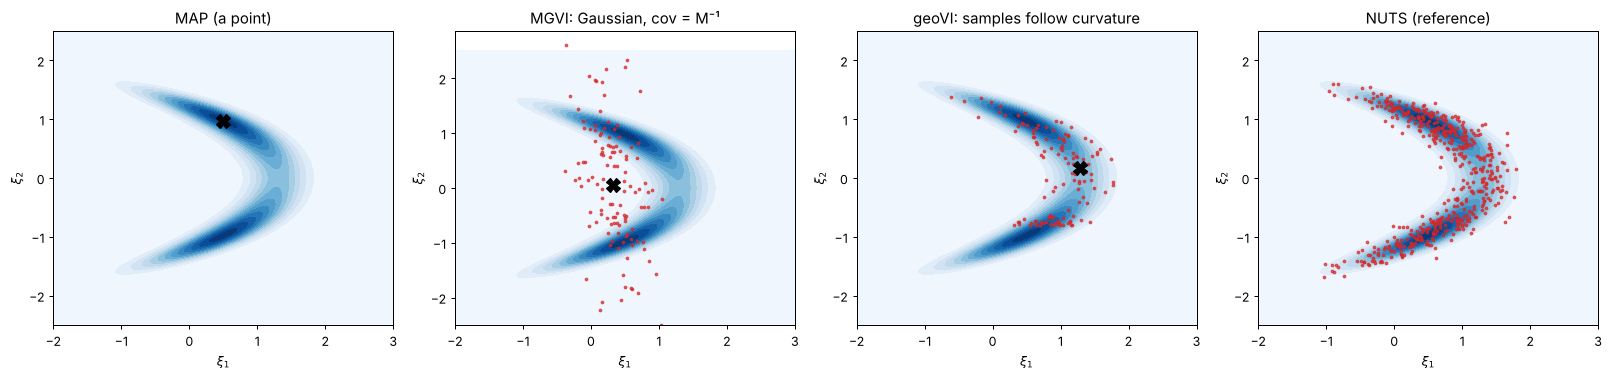

MGVI   mean = [0.331 0.057]   std = [0.302 1.073]
geoVI  mean = [0.911 0.092]   std = [0.44 0.68]
NUTS   mean = [0.618 0.026]   std = [0.596 0.905]


In [3]:
solver = dict(
    draw_linear_kwargs=dict(cg_name=None, cg_kwargs=dict(absdelta=1e-8, maxiter=50)),
    nonlinearly_update_kwargs=dict(minimize_kwargs=dict(name=None, xtol=1e-6, cg_kwargs=dict(name=None), maxiter=20)),
    kl_kwargs=dict(minimize_kwargs=dict(name=None, xtol=1e-6, cg_kwargs=dict(name=None), maxiter=30)),
)
init = jft.Vector({"xi1": jnp.array(0.0), "xi2": jnp.array(0.3)})   # start off the symmetry axis

smp_map, _ = jft.optimize_kl(lh, init, n_total_iterations=5, n_samples=0, key=random.PRNGKey(0), **solver)
smp_mgvi, _ = jft.optimize_kl(lh, init, n_total_iterations=6, n_samples=60, key=random.PRNGKey(1),
                              sample_mode="linear_resample", **solver)
smp_geo, _ = jft.optimize_kl(lh, init, n_total_iterations=6, n_samples=60, key=random.PRNGKey(2),
                             sample_mode="nonlinear_resample", **solver)
smp_nuts, _ = jft.blackjax_nuts(lh, {"xi1": jnp.array(0.0), "xi2": jnp.array(0.3)}, random.PRNGKey(3),
                                n_warmup_steps=300, n_samples=1500)

pts_nuts = np.stack([np.asarray(smp_nuts.samples["xi1"]), np.asarray(smp_nuts.samples["xi2"])], 1)
fig, axs = plt.subplots(1, 4, figsize=(18, 4.3))
show(axs[0], mean=(float(smp_map.pos["xi1"]), float(smp_map.pos["xi2"])), title="MAP (a point)")
show(axs[1], as_pts(smp_mgvi), (float(smp_mgvi.pos["xi1"]), float(smp_mgvi.pos["xi2"])), "MGVI: Gaussian, cov = M⁻¹")
show(axs[2], as_pts(smp_geo), (float(smp_geo.pos["xi1"]), float(smp_geo.pos["xi2"])), "geoVI: samples follow curvature")
show(axs[3], pts_nuts[::3], None, "NUTS (reference)")
plt.tight_layout(); plt.show()

for name, pts in [("MGVI", as_pts(smp_mgvi)), ("geoVI", as_pts(smp_geo)), ("NUTS", pts_nuts)]:
    print(f"{name:6s} mean = {pts.mean(0).round(3)}   std = {pts.std(0).round(3)}")

**What you should see**
* **MAP** sits on one arm and reports no uncertainty.
* **MGVI** draws an ellipse aligned with the local Fisher metric at the mean — it can't bend.
* **geoVI** starts from the MGVI samples and pushes each through a non-linear map derived from the metric's
  geometry, so samples follow the banana's arm. In the latent space of a standardized model this usually helps
  a lot for large problems, where posteriors are *mildly* non-Gaussian.
* **NUTS** (Hamiltonian Monte Carlo) sees both arms. VI methods around a single mean cannot represent bimodality —
  be aware of symmetries (sign flips, label switching) in your models!

**Cost.** MGVI: 1 CG solve per sample. geoVI: plus one Newton-CG per sample. NUTS: many gradient evaluations per
sample and scales badly to $10^6$ parameters — use it to **validate** VI on small versions of your problem.

## 3. The `sample_mode` options
| value | meaning |
|---|---|
| `"linear_sample"` / `"linear_resample"` | MGVI. *resample* draws fresh samples each iteration; *sample* reuses the old random numbers |
| `"nonlinear_sample"` / `"nonlinear_resample"` | geoVI (default `nonlinear_resample`) |
| `"nonlinear_update"` | keep the samples and only update them non-linearly — cheap refinement in late iterations |

`sample_mode` and `n_samples` may be **functions of the iteration index** — the standard expert recipe is
"cheap and few early, accurate and many late":

In [4]:
smp_sched, state = jft.optimize_kl(
    lh, init, n_total_iterations=8, key=random.PRNGKey(4),
    n_samples=lambda i: 5 if i < 3 else 50,
    sample_mode=lambda i: "linear_resample" if i < 3 else "nonlinear_resample",
    callback=lambda samples, st: print(f"  iter {st.nit}: mean xi = ({float(samples.pos['xi1']):.3f}, {float(samples.pos['xi2']):.3f}), n_samples={len(samples)}"),
    **solver,
)

OPTIMIZE_KL: Starting 0001


OPTIMIZE_KL: Iteration 0001 E:+4.1409e+00
OPTIMIZE_KL: Linear sampling status (0, 0, 0, 0, 0)
OPTIMIZE_KL: #(KL minimization steps) 6
OPTIMIZE_KL: Likelihood residual(s):
'reduced Chi²:     3.4±     3.9, avg:  +0.0087±     1.3, #dof:      2'

OPTIMIZE_KL: Prior residual(s):
xi1                     :: 'reduced Chi²:    0.85±    0.69, avg:    +0.83±     0.4, #dof:      1'
xi2                     :: 'reduced Chi²:    0.56±    0.84, avg:    +0.28±     0.7, #dof:      1'




OPTIMIZE_KL: Starting 0002


  iter 1: mean xi = (0.831, 0.276), n_samples=10


CG: gamma=0, converged!


...

CG: WARNING: energy increased


CG: WARNING: energy increased


N: Iteration Limit Reached


OPTIMIZE_KL: Iteration 0008 E:+1.5607e+00
OPTIMIZE_KL: #(Nonlinear sampling steps) (3, 3, 4, 20, 3, 4, 4, 4, 4, 10, 3, 4, 3, 3, 3, 4, 4, 20, 4, 20, 20, 4, 20, 4, 5, 20, 4, 10, 3, 3, 20, 4, 3, 3, 4, 20, 3, 3, 20, 4, 4, 20, 3, 3, 20, 4, 3, 3, 3, 4, 20, 4, 4, 3, 20, 4, 20, 4, 2, 2, 4, 13, 5, 15, 3, 3, 20, 4, 15, 5, 3, 4, 20, 4, 3, 3, 5, 17, 20, 4, 8, 4, 4, 20, 4, 4, 4, 3, 4, 20, 2, 2, 4, 11, 4, 9, 4, 20, 20, 4)
OPTIMIZE_KL: #(KL minimization steps) 6
OPTIMIZE_KL: Likelihood residual(s):
'reduced Chi²:    0.77±    0.81, avg:  -0.0055±    0.65, #dof:      2'

OPTIMIZE_KL: Prior residual(s):
xi1                     :: 'reduced Chi²:     1.1±    0.82, avg:     +0.9±    0.53, #dof:      1'
xi2                     :: 'reduced Chi²:    0.48±    0.48, avg:    +0.17±    0.67, #dof:      1'




  iter 8: mean xi = (1.272, 0.236), n_samples=100


## 4. `point_estimates` and `constants`
* `point_estimates=("xi1",)` — optimise these parameters but **don't sample** them (MAP for a subset). Handy for nuisance parameters that are well constrained or very expensive to sample.
* `constants=("xi1",)` — keep these parameters fixed at the initial value (neither optimised nor sampled).

In [5]:
smp_pe, _ = jft.optimize_kl(lh, init, n_total_iterations=6, n_samples=50, key=random.PRNGKey(5),
                            point_estimates=("xi1",), **solver)
pe = as_pts(smp_pe)
print("xi1 spread with point_estimates=('xi1',):", pe[:, 0].std().round(6), " | xi2 spread:", pe[:, 1].std().round(3))

OPTIMIZE_KL: Starting 0001


CG: gamma=0, converged!


CG: gamma=0, converged!


CG: gamma=0, converged!


CG: gamma=0, converged!


...

CG: gamma=0, converged!


CG: gamma=0, converged!


N: WARNING: Energy would increase; aborting


OPTIMIZE_KL: Iteration 0006 E:+1.2456e+00
OPTIMIZE_KL: #(Nonlinear sampling steps) (6, 3, 4, 3, 2, 4, 3, 3, 5, 3, 3, 5, 5, 4, 1, 4, 4, 4, 3, 3, 6, 3, 4, 2, 5, 5, 3, 4, 5, 2, 4, 3, 5, 4, 4, 3, 3, 4, 5, 4, 4, 1, 3, 5, 3, 5, 5, 4, 3, 3, 4, 5, 3, 3, 1, 4, 3, 5, 4, 3, 4, 2, 2, 4, 4, 3, 5, 2, 4, 3, 3, 5, 4, 5, 4, 4, 3, 5, 5, 3, 5, 2, 4, 3, 4, 3, 5, 2, 1, 4, 3, 3, 2, 4, 3, 3, 3, 4, 4, 2)
OPTIMIZE_KL: #(KL minimization steps) 26
OPTIMIZE_KL: Likelihood residual(s):
'reduced Chi²:    0.47±    0.21, avg:   -0.064±    0.18, #dof:      2'

OPTIMIZE_KL: Prior residual(s):
xi1                     :: 'reduced Chi²:     1.4± 4.4e-16, avg:     +1.2±     0.0, #dof:      1'
xi2                     :: 'reduced Chi²:    0.14±    0.11, avg:    +0.17±    0.33, #dof:      1'




xi1 spread with point_estimates=('xi1',): 0.0  | xi2 spread: 0.331


## 5. Saving and resuming long runs: `odir` and `resume`
Real reconstructions run for hours. Pass `odir="results"` to write the state (and a `minisanity.txt` log) after
every iteration; pass `resume=True` to continue from the last saved iteration after a crash.

```python
samples, state = jft.optimize_kl(lh, init, ..., odir="results_run1", resume=True)
```

## 6. Diagnostics: `jft.minisanity` — are the residuals the size of the noise?

For each sample, compute **normalised residuals** $(d - R(s))/\sigma$. If the model is right, they're
~$\mathcal N(0,1)$, so the **reduced χ²** ≈ 1. Same check for the latents: $\xi$ should look standard-normal.
* χ²/n ≫ 1 → model can't fit the data (noise underestimated, response wrong, prior too stiff).
* χ²/n ≪ 1 → over-fitting (noise overestimated).

In [6]:
stats, text = jft.minisanity(smp_geo, lh.normalized_residual)
print("Data residuals:\n", text)
stats, text = jft.minisanity(smp_geo)
print("Latent parameters:\n", text)

Data residuals:
 'reduced Chi²:    0.67±    0.59, avg:  -0.0072±    0.59, #dof:      2'

Latent parameters:
 xi1                     :: 'reduced Chi²:     1.0±    0.72, avg:    +0.91±    0.44, #dof:      1'
xi2                     :: 'reduced Chi²:    0.47±     0.4, avg:   +0.092±    0.68, #dof:      1'



## 7. Model comparison with the ELBO

The **evidence lower bound** $\text{ELBO} = \langle \ln P(d,\xi) \rangle_Q + \text{entropy}(Q) \le \ln P(d)$ lets you compare models.
Example: data generated by a straight line; compare a *line* model with a *parabola* model.

In [7]:
key = random.PRNGKey(10)
x = jnp.linspace(-3, 3, 30)
y = 2.0 * x + 1.0 + 0.8 * random.normal(key, x.shape)

class Poly(jft.Model):
    def __init__(self, x, degree):
        self.x = x
        self.coeffs = jft.NormalPrior(0.0, 3.0, shape=(degree + 1,), name="c")
        super().__init__(init=self.coeffs.init)

    def __call__(self, xi):
        c = self.coeffs(xi)
        return sum(c[i] * self.x**i for i in range(c.shape[0]))

for deg in (1, 2, 5):
    m = Poly(x, deg)
    lh_p = jft.Gaussian(y, noise_std_inv=lambda r: r / 0.8).amend(m)
    smp, _ = jft.optimize_kl(lh_p, jft.Vector(lh_p.init(random.PRNGKey(deg))), n_total_iterations=4, n_samples=20,
                             key=random.PRNGKey(20 + deg), **solver)
    elbo, st = jft.estimate_evidence_lower_bound(lh_p, smp, n_eigenvalues=deg + 1, verbose=False)
    print(f"degree {deg}: ELBO = {float(st['elbo_mean']):8.3f}   (1σ range {float(st['elbo_lw']):.2f} … {float(st['elbo_up']):.2f})")

assuming a diagonal covariance matrix;
setting `cov_inv` to `std_inv(ones_like(data))**2`


OPTIMIZE_KL: Starting 0001


OPTIMIZE_KL: Iteration 0001 E:+1.1806e+01
OPTIMIZE_KL: #(Nonlinear sampling steps) (1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1)
OPTIMIZE_KL: #(KL minimization steps) 2
OPTIMIZE_KL: Likelihood residual(s):
'reduced Chi²:    0.77±    0.12, avg:  +0.0027±    0.25, #dof:     30'

OPTIMIZE_KL: Prior residual(s):
c                       :: 'reduced Chi²:    0.29±   0.025, avg:     +0.5±   0.034, #dof:      2'




OPTIMIZE_KL: Starting 0002


CG: gamma=0, converged!


...

OPTIMIZE_KL: Starting 0003


OPTIMIZE_KL: Iteration 0003 E:+1.2945e+01
OPTIMIZE_KL: #(Nonlinear sampling steps) (1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1)
OPTIMIZE_KL: #(KL minimization steps) 1
OPTIMIZE_KL: Likelihood residual(s):
'reduced Chi²:    0.84±    0.11, avg:  +0.0027±    0.15, #dof:     30'

OPTIMIZE_KL: Prior residual(s):
c                       :: 'reduced Chi²:    0.11±   0.026, avg:    +0.17±   0.012, #dof:      6'




OPTIMIZE_KL: Starting 0004


OPTIMIZE_KL: Iteration 0004 E:+1.2391e+01
OPTIMIZE_KL: #(Nonlinear sampling steps) (1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1)
OPTIMIZE_KL: #(KL minimization steps) 1
OPTIMIZE_KL: Likelihood residual(s):
'reduced Chi²:     0.8±     0.1, avg:  +0.0027±    0.15, #dof:     30'

OPTIMIZE_KL: Prior residual(s):
c                       :: 'reduced Chi²:    0.11±   0.038, avg:    +0.17±    0.02, #dof:      6'




degree 5: ELBO =  -34.983   (1σ range -36.56 … -33.41)


The line wins: higher-degree models fit the data no better but "waste" prior volume (Occam's razor, built in).
Caveat: the ELBO omits constants that don't depend on the parameters (e.g. $-\frac12\ln|2\pi N|$) — fine for
comparing models with the **same likelihood and data**; add them back otherwise.

## ✏️ Exercises
**E4.1** Make the banana less curved (`noise_std = [0.3, 0.1]`: $\xi_1$ is now measured precisely). When do MGVI and geoVI agree?

**E4.2** Start `init` *exactly* on the symmetry axis (`xi2 = 0`). What happens to MAP and to geoVI? Why? (Hint: gradient w.r.t. $\xi_2$.)

**E4.3** Run MGVI with `n_samples=2` vs `n_samples=200`. Plot the mean trajectory over iterations using a `callback`. How noisy is the KL optimisation?

**E4.4** Add a degree-1 model with **unknown noise** (`VariableCovarianceGaussian`, see Hands-on 1) and compare its ELBO to the fixed-noise line. *(Careful: different likelihoods → constants matter!)*

In [8]:
# Your work here

---
## Solutions

OPTIMIZE_KL: Starting 0001


CG: gamma=0, converged!


OPTIMIZE_KL: Iteration 0001 E:+1.3867e+00
OPTIMIZE_KL: #(KL minimization steps) 2
OPTIMIZE_KL: Likelihood residual(s):
'reduced Chi²:    0.53±     0.0, avg:   -0.087±     0.0, #dof:      2'

OPTIMIZE_KL: Prior residual(s):
xi1                     :: 'reduced Chi²:     1.7±     0.0, avg:     +1.3±     0.0, #dof:      1'
xi2                     :: 'reduced Chi²:     0.0±     0.0, avg:     +0.0±     0.0, #dof:      1'




OPTIMIZE_KL: Starting 0002


CG: gamma=0, converged!


...

CG: WARNING: energy increased


CG: WARNING: energy increased


N: Iteration Limit Reached


CG: gamma=0, converged!


OPTIMIZE_KL: Iteration 0006 E:+1.4136e+00
OPTIMIZE_KL: #(Nonlinear sampling steps) (20, 4, 4, 14, 4, 20, 4, 6, 3, 4, 3, 3, 3, 4, 4, 4, 20, 4, 20, 4, 20, 4, 4, 3, 20, 4, 20, 4, 3, 4, 4, 20, 4, 20, 4, 9, 4, 5, 19, 5, 4, 20, 14, 4, 20, 4, 20, 4, 4, 4, 4, 20, 4, 20, 3, 3, 20, 4, 4, 20, 4, 20, 4, 20, 18, 5, 20, 4, 4, 20, 4, 4, 4, 20, 3, 4, 3, 3, 20, 4, 4, 20, 20, 4, 20, 4, 20, 4, 4, 10, 3, 3, 3, 3, 3, 3, 10, 4, 3, 3, 3, 4, 4, 12, 20, 4, 4, 20, 4, 20, 3, 3, 20, 4, 4, 20, 20, 4, 3, 3)
OPTIMIZE_KL: #(KL minimization steps) 4
OPTIMIZE_KL: Likelihood residual(s):
'reduced Chi²:    0.65±    0.64, avg:   +0.052±    0.59, #dof:      2'

OPTIMIZE_KL: Prior residual(s):
xi1                     :: 'reduced Chi²:    0.72±    0.79, avg:    +0.62±    0.58, #dof:      1'
xi2                     :: 'reduced Chi²:    0.82±    0.61, avg:  +0.0017±     0.9, #dof:      1'




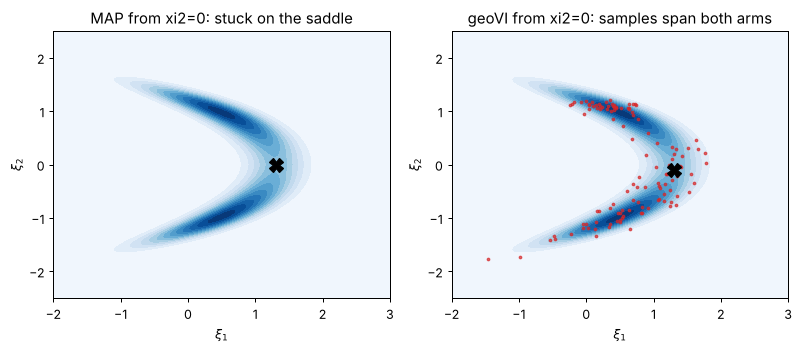

In [9]:
# E4.2 — on the symmetry axis the gradient wrt xi2 vanishes (d/dxi2 of xi2^2 at 0 is 0): MAP gets stuck on a saddle.
init0 = jft.Vector({"xi1": jnp.array(0.0), "xi2": jnp.array(0.0)})
s_map0, _ = jft.optimize_kl(lh, init0, n_total_iterations=5, n_samples=0, key=random.PRNGKey(0), **solver)
s_geo0, _ = jft.optimize_kl(lh, init0, n_total_iterations=6, n_samples=60, key=random.PRNGKey(2), **solver)
fig, axs = plt.subplots(1, 2, figsize=(9, 4))
show(axs[0], mean=(float(s_map0.pos["xi1"]), float(s_map0.pos["xi2"])), title="MAP from xi2=0: stuck on the saddle")
show(axs[1], as_pts(s_geo0), (float(s_geo0.pos["xi1"]), float(s_geo0.pos["xi2"])), "geoVI from xi2=0: samples span both arms")
plt.tight_layout(); plt.show()